# Linear Model Training on Neurosoft Minipigs 2026

Minimal example: load a single session, extract fixed-length windows using
torch_brain's `SequentialFixedWindowSampler`, and train a logistic regression
on the **on_vs_off** binary classification task (intrasession split).

In [1]:
%matplotlib inline

In [2]:
import numpy as np
import scipy.signal as sps
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

from torch_brain.data.sampler import SequentialFixedWindowSampler

from auditorydecoding.datasets.neurosoft_minipigs_2026.NeurosoftMinipgs2026 import (
    NeurosoftMinipigs2026,
)

In [3]:
DATA_ROOT = "../data/processed"
RECORDING_ID = "sub-02_ses-01_task-AcousticStim_desc-raw_LH"

WINDOW_LENGTH = 0.5  # seconds
FOLD_NUM = 0
SPLIT_TYPE = "intrasession"
TASK_TYPE = "on_vs_off"
BALANCE_CLASSES = True

In [4]:
dataset = NeurosoftMinipigs2026(
    root=DATA_ROOT,
    recording_ids=[RECORDING_ID],
    fold_num=FOLD_NUM,
    split_type=SPLIT_TYPE,
    task_type=TASK_TYPE,
)

print(f"Recording IDs: {dataset.recording_ids}")

for split in ("train", "valid", "test"):
    intervals = dataset.get_sampling_intervals(split=split)
    for rid, iv in intervals.items():
        n = len(iv.start)
        dur = sum(iv.end - iv.start)
        print(f"  {split:>5s}: {n:4d} intervals, {dur:7.1f}s total")

Recording IDs: ['sub-02_ses-01_task-AcousticStim_desc-raw_LH']
  train: 1340 intervals,   864.0s total
  valid:  336 intervals,   168.0s total
   test:  838 intervals,   660.2s total


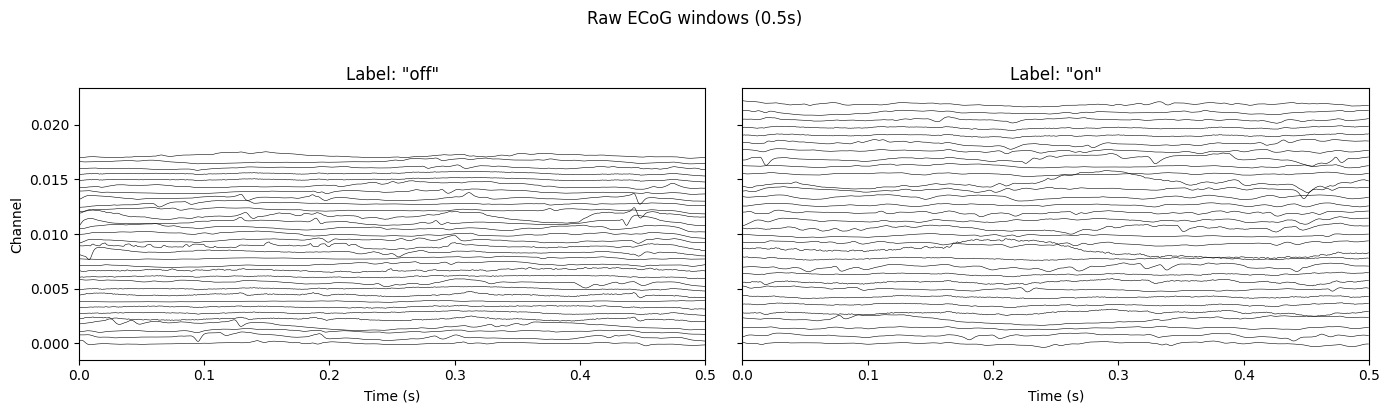

In [5]:
train_intervals = dataset.get_sampling_intervals(split="train")
rid = dataset.recording_ids[0]
intervals = train_intervals[rid]
labels = intervals.behavior_labels

on_idx = np.where(labels == "on")[0][0]
off_idx = np.where(labels == "off")[0][0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, idx, title in [
    (axes[0], off_idx, "off"),
    (axes[1], on_idx, "on"),
]:
    start, end = intervals.start[idx], intervals.end[idx]
    sample = dataset.get_recording(rid).slice(start, start + WINDOW_LENGTH)
    signal = sample.ecog.signal
    t = np.arange(signal.shape[0]) / (signal.shape[0] / WINDOW_LENGTH)

    spacing = 4 * np.std(signal)
    for ch in range(signal.shape[1]):
        ax.plot(t, signal[:, ch] + ch * spacing, linewidth=0.4, color="k")

    ax.set_title(f'Label: "{title}"')
    ax.set_xlabel("Time (s)")
    ax.set_xlim(0, WINDOW_LENGTH)

axes[0].set_ylabel("Channel")
fig.suptitle(f"Raw ECoG windows ({WINDOW_LENGTH}s)", y=1.02)
fig.tight_layout()
plt.show()

In [6]:
def extract_features(signal, mode="mean", n_samples=None):
    """Convert a (n_timepoints, n_channels) signal window into a flat feature vector.

    Modes
    -----
    "mean"     : channel-wise mean              -> (n_channels,)
    "signal"   : flatten raw signal             -> (n_timepoints * n_channels,)
    "resample" : resample then flatten          -> (n_samples * n_channels,)
    "fft"      : rfft magnitude per channel     -> (n_freq_bins * n_channels,)
    """
    if mode == "mean":
        return signal.mean(axis=0)
    if mode == "signal":
        return signal.flatten()
    if mode == "resample":
        return sps.resample(signal, n_samples, axis=0).flatten()
    if mode == "fft":
        return np.abs(np.fft.rfft(signal, axis=0)).flatten()
    raise ValueError(f"Unknown feature mode '{mode}'")

In [7]:
def extract_windows(
    dataset,
    split,
    window_length,
    label_field="on_vs_off_trials",
    feature_mode="mean",
    n_samples=None,
):
    """Iterate over all sampler windows and return (X, y) numpy arrays."""
    intervals = dataset.get_sampling_intervals(split=split)
    sampler = SequentialFixedWindowSampler(
        sampling_intervals=intervals,
        window_length=window_length,
        drop_short=True,
    )

    X, y = [], []
    for index in sampler:
        sample = dataset[index]
        features = extract_features(
            sample.ecog.signal, mode=feature_mode, n_samples=n_samples
        )
        label = getattr(sample, label_field).behavior_labels[0]
        X.append(features)
        y.append(label)

    return np.stack(X), np.array(y)

In [8]:
FEATURE_MODE = "signal"

X_train, y_train = extract_windows(
    dataset, "train", WINDOW_LENGTH, feature_mode=FEATURE_MODE
)
X_valid, y_valid = extract_windows(
    dataset, "valid", WINDOW_LENGTH, feature_mode=FEATURE_MODE
)
X_test, y_test = extract_windows(
    dataset, "test", WINDOW_LENGTH, feature_mode=FEATURE_MODE
)

le = LabelEncoder().fit(y_train)
y_train_enc = le.transform(y_train)
y_valid_enc = le.transform(y_valid)
y_test_enc = le.transform(y_test)

for name, X, y in [
    ("train", X_train, y_train),
    ("valid", X_valid, y_valid),
    ("test", X_test, y_test),
]:
    unique, counts = np.unique(y, return_counts=True)
    dist = ", ".join(f"{u}: {c}" for u, c in zip(unique, counts))
    print(f"{name:>5s}  X={X.shape}  y={y.shape}  classes={{ {dist} }}")

train  X=(1728, 32000)  y=(1728,)  classes={ off: 1056, on: 672 }
valid  X=(336, 32000)  y=(336,)  classes={ off: 168, on: 168 }
 test  X=(1322, 32000)  y=(1322,)  classes={ off: 902, on: 420 }


In [9]:
if BALANCE_CLASSES:
    rng = np.random.default_rng(42)
    classes, counts = np.unique(y_train_enc, return_counts=True)
    min_count = counts.min()

    balanced_idx = np.concatenate([
        rng.choice(np.where(y_train_enc == c)[0], size=min_count, replace=False)
        for c in classes
    ])
    balanced_idx.sort()
    X_train, y_train, y_train_enc = (
        X_train[balanced_idx],
        y_train[balanced_idx],
        y_train_enc[balanced_idx],
    )

    for name, X, y in [
        ("train (balanced)", X_train, y_train),
        ("valid", X_valid, y_valid),
        ("test", X_test, y_test),
    ]:
        unique, cnt = np.unique(y, return_counts=True)
        dist = ", ".join(f"{u}: {c}" for u, c in zip(unique, cnt))
        print(f"{name:>20s}  X={X.shape}  classes={{ {dist} }}")

    train (balanced)  X=(1344, 32000)  classes={ off: 672, on: 672 }
               valid  X=(336, 32000)  classes={ off: 168, on: 168 }
                test  X=(1322, 32000)  classes={ off: 902, on: 420 }


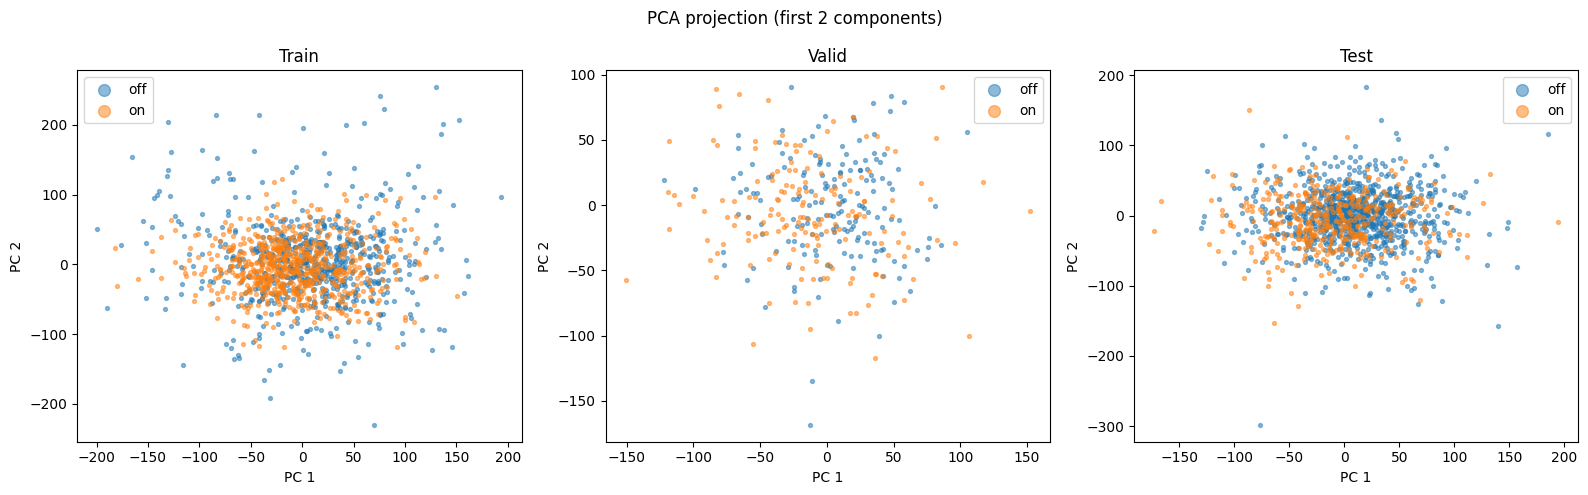

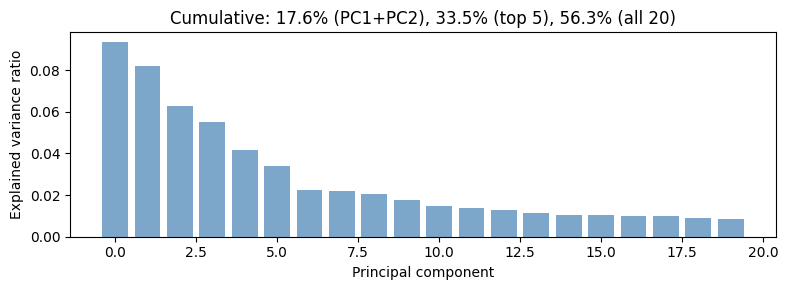

In [10]:
scaler = StandardScaler().fit(X_train)
pca = PCA(n_components=min(20, X_train.shape[1])).fit(scaler.transform(X_train))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, X, y_enc, title in [
    (axes[0], X_train, y_train_enc, "Train"),
    (axes[1], X_valid, y_valid_enc, "Valid"),
    (axes[2], X_test, y_test_enc, "Test"),
]:
    Z = pca.transform(scaler.transform(X))
    for c, label in enumerate(le.classes_):
        mask = y_enc == c
        ax.scatter(Z[mask, 0], Z[mask, 1], s=8, alpha=0.5, label=label)
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.set_title(title)
    ax.legend(markerscale=3)

fig.suptitle("PCA projection (first 2 components)")
fig.tight_layout()
plt.show()

explained = pca.explained_variance_ratio_
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(len(explained)), explained, color="steelblue", alpha=0.7)
ax.set_xlabel("Principal component")
ax.set_ylabel("Explained variance ratio")
ax.set_title(
    f"Cumulative: {explained[:2].sum():.1%} (PC1+PC2), "
    f"{explained[:5].sum():.1%} (top 5), "
    f"{explained.sum():.1%} (all {len(explained)})"
)
fig.tight_layout()
plt.show()

In [11]:
clf = LogisticRegression(max_iter=100000)
clf.fit(X_train, y_train_enc)

val_acc = accuracy_score(y_valid_enc, clf.predict(X_valid))
test_acc = accuracy_score(y_test_enc, clf.predict(X_test))

print(f"Validation accuracy: {val_acc:.3f}")
print(f"Test accuracy:       {test_acc:.3f}")
print()
print(
    classification_report(
        y_test_enc,
        clf.predict(X_test),
        target_names=le.classes_,
    )
)

Validation accuracy: 0.500
Test accuracy:       0.682

              precision    recall  f1-score   support

         off       0.68      1.00      0.81       902
          on       0.00      0.00      0.00       420

    accuracy                           0.68      1322
   macro avg       0.34      0.50      0.41      1322
weighted avg       0.47      0.68      0.55      1322



/home/mila/s/sobralm/auditorydecoding/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mila/s/sobralm/auditorydecoding/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mila/s/sobralm/auditorydecoding/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

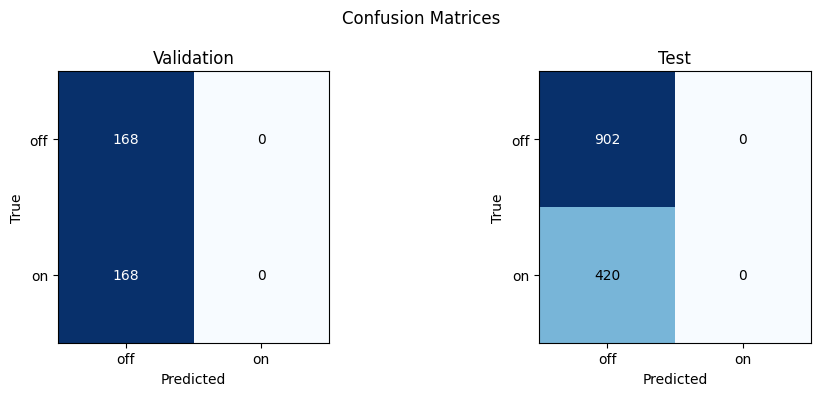

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, y_true, y_pred, title in [
    (axes[0], y_valid_enc, clf.predict(X_valid), "Validation"),
    (axes[1], y_test_enc, clf.predict(X_test), "Test"),
]:
    cm = confusion_matrix(y_true, y_pred)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(le.classes_)))
    ax.set_yticks(range(len(le.classes_)))
    ax.set_xticklabels(le.classes_)
    ax.set_yticklabels(le.classes_)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i, j] > cm.max() / 2 else "black"
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color)

fig.suptitle("Confusion Matrices")
fig.tight_layout()
plt.show()